# Exercise
### Notebook created by Keshav Sriram Kumar

For this exercise you are going to try to try and predict the carat range of a diamond based on some of its properties.  Start by importing the standard libraries and reading in the 'diamonds.csv' file. 

Drop the 'Color', 'Clarity', and 'Unnamed: 0' Columns.

You will need to change the 'cut' values into int values.

Referencing what we did in week 5, create a new column for carat ranges with the values '0-1', '1-2','2-3','3-4','4-5','5-6'

Drop the column 'carat' after you have created the carat ranges column

Using K-Nearest Neighbours classify your carat ranges based on the other values in your dataframe.  Print out an accuracy score and a classification report for your algorithm.

Create a diagram of error rates for different values of K.  What value of K will give you a more accurate result?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

diamonds = pd.read_csv('diamonds.csv')

In [2]:
diamonds.head(10)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,8,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,9,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,10,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [3]:
diamonds['cut'].unique()

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [4]:
diamonds.drop('Unnamed: 0', axis=1, inplace=True)
diamonds.drop('color', axis=1, inplace=True)
diamonds.drop('clarity', axis=1, inplace=True)

In [5]:
diamonds.replace('Ideal', 0, inplace=True)
diamonds.replace('Premium', 1, inplace=True)
diamonds.replace('Good', 2, inplace=True)
diamonds.replace('Very Good', 3, inplace=True)
diamonds.replace('Fair', 4, inplace=True)

diamonds.dropna(axis=0, inplace=True)

diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   carat   53940 non-null  float64
 1   cut     53940 non-null  int64  
 2   depth   53940 non-null  float64
 3   table   53940 non-null  float64
 4   price   53940 non-null  int64  
 5   x       53940 non-null  float64
 6   y       53940 non-null  float64
 7   z       53940 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 3.3 MB


C:\Users\kesha\AppData\Local\Temp\ipykernel_20000\1588442227.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  diamonds.replace('Fair', 4, inplace=True)


In [6]:
# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)

In [7]:
carat_bins = [0, 1, 2, 3, 4, 5, 6]

diamonds['carat'] = pd.cut(diamonds['carat'], bins=carat_bins, labels=['0-1','1-2','2-3','3-4','4-5','5-6'])


In [8]:
X, y = diamonds.drop('carat', axis=1), diamonds['carat'].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=87)

In [9]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train,y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [10]:
knn.score(X_test, y_test)

0.8957483623779509

In [11]:
predictions = knn.predict(X_test)

In [12]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

         0-1       0.95      0.94      0.95     10927
         1-2       0.81      0.83      0.82      4652
         2-3       0.59      0.53      0.56       593
         3-4       0.50      0.14      0.22         7
         4-5       1.00      0.33      0.50         3

    accuracy                           0.90     16182
   macro avg       0.77      0.56      0.61     16182
weighted avg       0.90      0.90      0.90     16182



In [13]:
error_rate = []

# Will take some time
for i in range(1,80):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

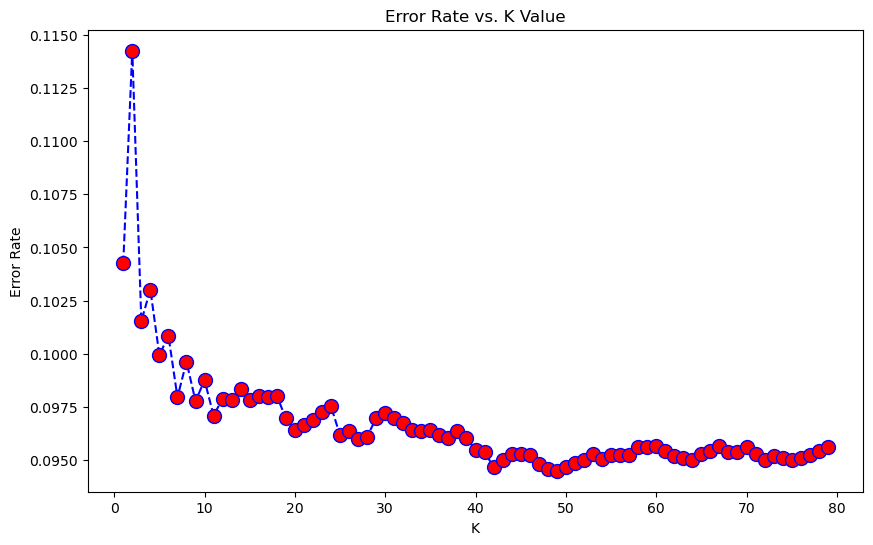

In [14]:
plt.figure(figsize=(10,6))
plt.plot(range(1,80),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')